# Membro 1 — EfficientNet (B2 → B3)
## Aplicação de Sistemas Inteligentes — Comparativo de Arquiteturas CNN

| Variação | Peso | Backbone | Épocas | Resolução | LR |
|---|---|---|---|---|---|
| V1 | Muito Leve | EfficientNet-B2 100% congelado | 12 | 224 | 1e-3 |
| V2 | Muito Leve | EfficientNet-B2 congelado + Dropout | 15 | 224 | 1e-3 |
| V3 | Leve | EfficientNet-B2 último bloco livre | 22 | 224 | 1e-4 |
| V4 | Leve | EfficientNet-B2 último bloco + Scheduler | 25 | 224 | 1e-4 |
| V5 | Médio | EfficientNet-B2 2 blocos livres | 35 | 224 | 5e-5 |
| V6 | Médio | EfficientNet-B2 2 blocos + 256px | 40 | 256 | 5e-5 |
| V7 | Pesado | EfficientNet-B3 FT completo + TTA | 55 | 256 | 1e-5 |
| V8 | Pesado | EfficientNet-B3 FT completo + SE + TTA | 60 | 299 | 1e-5 |

> **Registrar para cada variação:** Accuracy · F1 Macro · Precision · Recall · Loss · Tempo (min) · curvas treino/val · matriz de confusão


## 1 · Instalação de dependências

In [1]:
import importlib

required = [
    "torch",
    "torchvision",
    "timm",
    "sklearn",
    "matplotlib",
]

missing = []

for pkg in required:
    if importlib.util.find_spec(pkg) is None:
        missing.append(pkg)

if missing:
    print("Pacotes faltando:", missing)
else:
    print("✅ Todas as dependências instaladas")


✅ Todas as dependências instaladas


## 2 · Imports e configuração global

In [2]:
import os, time, itertools, joblib
from pathlib import Path
from copy import deepcopy

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import timm
from sklearn.metrics import (classification_report, confusion_matrix,
                              f1_score, precision_score, recall_score)
from sklearn.model_selection import StratifiedShuffleSplit
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from torchvision.models import (
    efficientnet_b2, EfficientNet_B2_Weights,
    efficientnet_b3, EfficientNet_B3_Weights,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")


Device: cuda
GPU: NVIDIA GeForce RTX 3060 Laptop GPU


## 3 · Configuração do dataset
> ⚠️ **Ajuste `DATA_ROOT` para apontar para a sua pasta de imagens.**
> A pasta deve ter subpastas por classe (padrão `ImageFolder`).

In [3]:
# ─── CONFIGURE AQUI ───────────────────────────────────────────────────────
DATA_ROOT = Path("..\\data_sets\\ovarian_ultrasound_dataset")
# ──────────────────────────────────────────────────────────────────────────

if not DATA_ROOT.exists():
    raise FileNotFoundError(
        f"\n❌ Pasta não encontrada: {DATA_ROOT.resolve()}"
        f"\n   Ajuste DATA_ROOT na célula acima."
    )

# Detecta se já há split train/validation pré-definido
use_predefined_split = (
    (DATA_ROOT / "train").exists() and
    (DATA_ROOT / "validation").exists()
)

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Verificação rápida de classes
_probe = datasets.ImageFolder(DATA_ROOT / "train" if use_predefined_split else DATA_ROOT)
CLASS_NAMES = _probe.classes
NUM_CLASSES = len(CLASS_NAMES)

print(f"Dataset  : {DATA_ROOT.resolve()}")
print(f"Classes  : {CLASS_NAMES}  ({NUM_CLASSES} classes)")
print(f"Split    : {'pré-definido (train/validation)' if use_predefined_split else 'gerado automaticamente 80/20 estratificado'}")


Dataset  : C:\Users\brian\Desktop\Uni\sistemas_int\ovary\data_sets\ovarian_ultrasound_dataset
Classes  : ['Dominant_Follicle', 'Normal', 'PCO']  (3 classes)
Split    : gerado automaticamente 80/20 estratificado


## 4 · Pipeline de dados (modular)
As transformações são definidas por nível de augmentation para reaproveitamento em todas as variações.

In [4]:
def get_transforms(aug_level: str, img_size: int = 224):
    """
    aug_level:
        'minimal'  → flip H
        'minimal_rot' → flip H + rotação ±10°  (V2 EfficientNet)
        'light'    → flip H/V + rot ±15°
        'light_jitter' → flip + jitter cor leve
        'moderate' → flip + rot + jitter cor + blur
        'moderate_crop' → flip + rot + jitter + RandomCrop
        'heavy'    → flip + rot + jitter + RandomErasing
    """
    normalize = transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)

    aug_map = {
        "minimal": [
            transforms.RandomHorizontalFlip(),
        ],
        "minimal_rot": [
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(10),
        ],
        "light": [
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.RandomRotation(15),
        ],
        "light_jitter": [
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.RandomRotation(15),
            transforms.ColorJitter(brightness=0.15, contrast=0.15),
        ],
        "moderate": [
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.RandomRotation(15),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
            transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),
        ],
        "moderate_crop": [
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.RandomRotation(15),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
            transforms.RandomResizedCrop(img_size, scale=(0.8, 1.0)),
        ],
        "heavy": [
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.RandomRotation(20),
            transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
        ],
    }

    pre_tensor = [transforms.Resize((img_size, img_size))] + aug_map[aug_level]
    post_tensor = [transforms.ToTensor(), normalize]

    if aug_level == "heavy":
        post_tensor.append(transforms.RandomErasing(p=0.3, scale=(0.02, 0.2)))

    train_tfms = transforms.Compose(pre_tensor + post_tensor)
    val_tfms   = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        normalize,
    ])
    return train_tfms, val_tfms


def make_loaders(train_tfms, val_tfms, batch_size=32):
    """Cria DataLoaders respeitando split pré-definido ou estratificado."""
    if use_predefined_split:
        train_ds = datasets.ImageFolder(DATA_ROOT / "train",      transform=train_tfms)
        val_ds   = datasets.ImageFolder(DATA_ROOT / "validation", transform=val_tfms)
    else:
        full_ds = datasets.ImageFolder(DATA_ROOT)
        targets = [y for _, y in full_ds.samples]
        sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
        train_idx, val_idx = next(sss.split(np.zeros(len(targets)), targets))

        train_ds_src = datasets.ImageFolder(DATA_ROOT, transform=train_tfms)
        val_ds_src   = datasets.ImageFolder(DATA_ROOT, transform=val_tfms)
        train_ds     = Subset(train_ds_src, train_idx)
        val_ds       = Subset(val_ds_src,   val_idx)

    nw = min(4, os.cpu_count() or 1) if device.type == "cuda" else 0
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=nw, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=nw, pin_memory=True)
    return train_loader, val_loader

print("✅ Pipeline de dados pronto")


✅ Pipeline de dados pronto


## 5 · Utilitários de treinamento

In [5]:
# ─── Loop de época ────────────────────────────────────────────────────────
def run_epoch(model, loader, optimizer=None, criterion=None, train=True, scheduler=None):
    model.train(mode=train)
    total_loss, total_correct, total = 0.0, 0, 0
    all_preds, all_targets = [], []

    with torch.set_grad_enabled(train):
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            if train:
                optimizer.zero_grad()
            logits = model(X)
            loss = criterion(logits, y)
            if train:
                loss.backward()
                optimizer.step()
            preds = logits.argmax(1)
            total_loss     += loss.item() * y.size(0)
            total_correct  += (preds == y).sum().item()
            total          += y.size(0)
            all_preds.append(preds.detach().cpu().numpy())
            all_targets.append(y.detach().cpu().numpy())

    avg_loss = total_loss / total
    acc      = total_correct / total
    y_true   = np.concatenate(all_targets)
    y_pred   = np.concatenate(all_preds)
    f1       = f1_score(y_true, y_pred, average="macro", zero_division=0)
    return avg_loss, acc, f1, y_true, y_pred


# ─── TTA (Test-Time Augmentation) ─────────────────────────────────────────
def tta_predict(model, loader, img_size=256, n_aug=4):
    """Flip H + crop central + rotação ±5° — média das probabilidades."""
    model.eval()
    all_probs, all_targets = [], []
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            probs = torch.softmax(model(X), dim=1)
            # flip horizontal
            probs_flip = torch.softmax(model(torch.flip(X, dims=[3])), dim=1)
            probs_avg = (probs + probs_flip) / 2
            all_probs.append(probs_avg.cpu())
            all_targets.append(y.cpu())
    probs_stack = torch.cat(all_probs, dim=0)
    targets_all  = torch.cat(all_targets, dim=0).numpy()
    preds = probs_stack.argmax(1).numpy()
    f1 = f1_score(targets_all, preds, average="macro", zero_division=0)
    acc = (preds == targets_all).mean()
    return acc, f1, targets_all, preds


# ─── Treinamento completo ──────────────────────────────────────────────────
def train_model(model, train_loader, val_loader, epochs, lr,
                scheduler_fn=None, label_smoothing=0.0, weight_decay=0.0,
                var_name="V?", use_tta=False, img_size=224, patience=25):
    """
    Treina e valida o modelo, registra histórico e retorna resultados.
    scheduler_fn: callable(optimizer) → scheduler  |  None
    Usa early stopping baseado em val_loss (patience).
    """
    criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=weight_decay
    )
    scheduler = scheduler_fn(optimizer) if scheduler_fn else None

    history = {k: [] for k in ["train_loss","val_loss","train_acc","val_acc","val_f1"]}
    best_state = None
    best_loss  = float('inf')
    best_f1    = 0.0
    best_yt, best_yp = None, None
    t0 = time.time()
    epochs_no_improve = 0

    for e in range(1, epochs + 1):
        tr_loss, tr_acc, _, _, _         = run_epoch(model, train_loader, optimizer, criterion, train=True)
        va_loss, va_acc, va_f1, yt, yp   = run_epoch(model, val_loader,   optimizer, criterion, train=False)

        if scheduler:
            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(va_loss)
            else:
                scheduler.step()

        for k, v in zip(history.keys(), [tr_loss, va_loss, tr_acc, va_acc, va_f1]):
            history[k].append(v)

        if va_loss < best_loss:
            best_loss  = va_loss
            best_f1    = va_f1
            best_state = deepcopy(model.state_dict())
            best_yt, best_yp = yt, yp
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"  Early stop na época {e}")
                break

        print(f"  [{e:>3}/{epochs}] loss {tr_loss:.4f}/{va_loss:.4f}  "
              f"acc {tr_acc:.4f}/{va_acc:.4f}  f1_val {va_f1:.4f}")

    elapsed = (time.time() - t0) / 60
    model.load_state_dict(best_state)

    if use_tta:
        print("  → Aplicando TTA...")
        tta_acc, tta_f1, best_yt, best_yp = tta_predict(model, val_loader, img_size)
        print(f"  TTA  acc={tta_acc:.4f}  f1={tta_f1:.4f}")
        final_acc, final_f1 = tta_acc, tta_f1
    else:
        final_acc = history["val_acc"][-1]
        final_f1  = best_f1

    precision = precision_score(best_yt, best_yp, average="macro", zero_division=0)
    recall    = recall_score   (best_yt, best_yp, average="macro", zero_division=0)

    results = {
        "variacao": var_name,
        "accuracy": round(final_acc, 4),
        "f1_macro": round(final_f1,  4),
        "precision": round(precision, 4),
        "recall":   round(recall,    4),
        "loss":     round(best_loss, 4),
        "tempo_min": round(elapsed, 1),
    }
    return model, history, results, best_yt, best_yp


# ─── Plots ────────────────────────────────────────────────────────────────
def plot_curves(history, var_name):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(history["train_loss"], label="train"); ax1.plot(history["val_loss"], label="val")
    ax1.set_title(f"{var_name} — Loss"); ax1.set_xlabel("epoch"); ax1.legend()
    ax2.plot(history["train_acc"],  label="train"); ax2.plot(history["val_acc"],  label="val")
    ax2.set_title(f"{var_name} — Accuracy"); ax2.set_xlabel("epoch"); ax2.legend()
    plt.tight_layout(); plt.show()

def plot_cm(y_true, y_pred, class_names, var_name, normalize=True):
    cm = confusion_matrix(y_true, y_pred)
    if normalize:
        cm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    plt.figure(figsize=(max(5, len(class_names)*1.2), max(4, len(class_names))))
    plt.imshow(cm, cmap="Blues")
    plt.title(f"{var_name} — Matriz de Confusão {'Normalizada' if normalize else ''}")
    plt.colorbar()
    ticks = np.arange(len(class_names))
    plt.xticks(ticks, class_names, rotation=45, ha="right")
    plt.yticks(ticks, class_names)
    fmt = ".2f" if normalize else "d"
    thresh = cm.max() / 2
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i,j], fmt), ha="center",
                 color="white" if cm[i,j] > thresh else "black", fontsize=9)
    plt.ylabel("Real"); plt.xlabel("Previsto")
    plt.tight_layout(); plt.show()

def show_results(res):
    print(f"\n{'─'*55}")
    print(f"  {res['variacao']} — Resultados Finais")
    print(f"{'─'*55}")
    print(f"  Accuracy   : {res['accuracy']:.4f}")
    print(f"  F1 Macro   : {res['f1_macro']:.4f}")
    print(f"  Precision  : {res['precision']:.4f}")
    print(f"  Recall     : {res['recall']:.4f}")
    print(f"  Loss (val) : {res['loss']:.4f}")
    print(f"  Tempo      : {res['tempo_min']} min")
    print(f"{'─'*55}")

print("✅ Utilitários de treinamento prontos")


✅ Utilitários de treinamento prontos


## 6 · Tabela de resultados
Acumula todas as variações automaticamente.

In [6]:
ALL_RESULTS = []   # preenchido automaticamente após cada variação

def print_results_table():
    if not ALL_RESULTS:
        print("Nenhum resultado ainda.")
        return
    header = f"{'Var':<6} {'Backbone':<30} {'Acc':>6} {'F1':>6} {'Prec':>6} {'Rec':>6} {'Loss':>6} {'Tempo':>6}"
    print(header)
    print("─" * len(header))
    for r in ALL_RESULTS:
        print(f"{r['variacao']:<6} {r.get('backbone','—'):<30} "
              f"{r['accuracy']:>6.4f} {r['f1_macro']:>6.4f} "
              f"{r['precision']:>6.4f} {r['recall']:>6.4f} "
              f"{r['loss']:>6.4f} {r['tempo_min']:>5.1f}m")

print("✅ Tabela pronta — execute print_results_table() a qualquer momento")


✅ Tabela pronta — execute print_results_table() a qualquer momento


In [7]:
# ─── Salvamento de modelos ────────────────────────────────────────────────
SAVE_DIR = Path("modelos_salvos") / "membro1"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

def save_model(model, var_name: str) -> Path:
    """
    Salva o modelo completo em .joblib dentro de SAVE_DIR.
    Nome do arquivo: membro1_<var_name_sanitizado>.joblib
    """
    safe = var_name.replace(" ", "_").replace("/", "-")
    path = SAVE_DIR / f"membro1_{safe}.joblib"
    joblib.dump(model, path)
    print(f"  💾 Modelo salvo → {path}")
    return path

print(f"✅ Função save_model pronta  |  pasta: {SAVE_DIR.resolve()}")


✅ Função save_model pronta  |  pasta: C:\Users\brian\Desktop\Uni\sistemas_int\ovary\image_augmentation\modelos_salvos\membro1


---
## V1 · Muito Leve — EfficientNet-B2 (100% congelado)

| Parâmetro | Valor |
|---|---|
| Backbone | EfficientNet-B2, ImageNet, 100% congelado |
| Cabeça | Linear(n_feat → n_cls) |
| Augmentation | Flip H |
| Scheduler | Nenhum |
| Épocas | 12 (early stop) |
| Resolução | 224 |
| LR | 1e-3 |

**Objetivo:** baseline zero. Mede o quão longe o pre-train ImageNet sozinho leva.


In [8]:
def build_v1():
    weights = EfficientNet_B2_Weights.IMAGENET1K_V1
    model = efficientnet_b2(weights=weights)
    for p in model.parameters():
        p.requires_grad = False
    in_feats = model.classifier[-1].in_features
    model.classifier[-1] = nn.Linear(in_feats, NUM_CLASSES)
    return model.to(device)

train_tfms_v1, val_tfms_v1 = get_transforms("minimal", img_size=224)
train_loader_v1, val_loader_v1 = make_loaders(train_tfms_v1, val_tfms_v1, batch_size=32)

model_v1 = build_v1()
trainable_v1 = sum(p.numel() for p in model_v1.parameters() if p.requires_grad)
total_v1     = sum(p.numel() for p in model_v1.parameters())
print(f"Parâmetros treináveis: {trainable_v1:,} / {total_v1:,}")


Downloading: "https://download.pytorch.org/models/efficientnet_b2_rwightman-c35c1473.pth" to C:\Users\brian/.cache\torch\hub\checkpoints\efficientnet_b2_rwightman-c35c1473.pth
100%|██████████| 35.2M/35.2M [00:00<00:00, 69.2MB/s]


Parâmetros treináveis: 4,227 / 7,705,221


In [9]:
print("\n=== Treinando V1 ===")
model_v1, hist_v1, res_v1, yt_v1, yp_v1 = train_model(
    model_v1, train_loader_v1, val_loader_v1,
    epochs=1000,
    lr=1e-3,
    var_name="V1 EffNet-B2 frozen",
)
res_v1["backbone"] = "EfficientNet-B2 (frozen)"
ALL_RESULTS.append(res_v1)
show_results(res_v1)

save_model(model_v1, res_v1["variacao"])


=== Treinando V1 ===
  [  1/1000] loss 0.9919/0.9319  acc 0.4208/0.5410  f1_val 0.3318
  [  2/1000] loss 0.8432/0.8551  acc 0.5500/0.5738  f1_val 0.4392
  [  3/1000] loss 0.7560/0.7686  acc 0.6708/0.7049  f1_val 0.6595
  [  4/1000] loss 0.6854/0.7189  acc 0.7583/0.8033  f1_val 0.8154
  [  5/1000] loss 0.6408/0.6880  acc 0.7583/0.7869  f1_val 0.8001
  [  6/1000] loss 0.6059/0.6509  acc 0.7958/0.7705  f1_val 0.7725
  [  7/1000] loss 0.5577/0.6304  acc 0.8083/0.7705  f1_val 0.7701
  [  8/1000] loss 0.5819/0.6267  acc 0.7667/0.7869  f1_val 0.7863
  [  9/1000] loss 0.5333/0.6200  acc 0.8042/0.7541  f1_val 0.7648
  [ 10/1000] loss 0.5289/0.6088  acc 0.8042/0.7869  f1_val 0.7863
  [ 11/1000] loss 0.4855/0.6039  acc 0.8500/0.7705  f1_val 0.7769
  [ 12/1000] loss 0.4981/0.5999  acc 0.8292/0.7705  f1_val 0.7652
  [ 13/1000] loss 0.4974/0.5946  acc 0.7917/0.7705  f1_val 0.7630
  [ 14/1000] loss 0.5275/0.5920  acc 0.7792/0.7705  f1_val 0.7759
  [ 15/1000] loss 0.4822/0.5951  acc 0.7875/0.7541  f1

WindowsPath('modelos_salvos/membro1/membro1_V1_EffNet-B2_frozen.joblib')

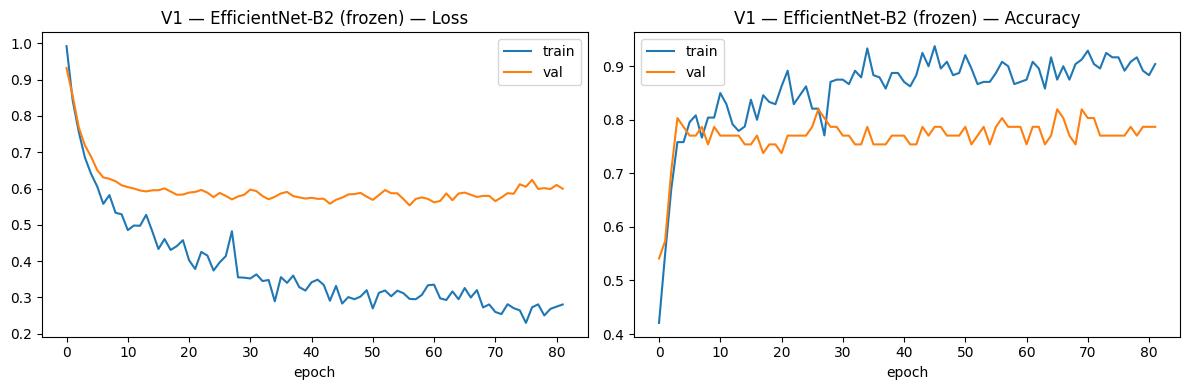

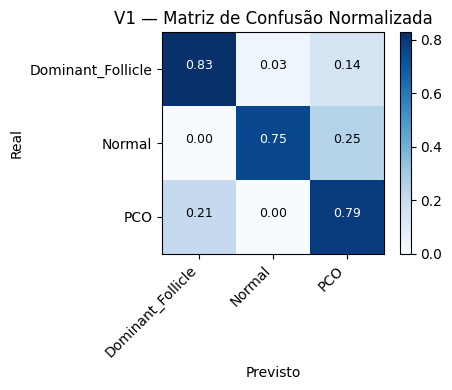

                   precision    recall  f1-score   support

Dominant_Follicle       0.83      0.83      0.83        29
           Normal       0.86      0.75      0.80         8
              PCO       0.76      0.79      0.78        24

         accuracy                           0.80        61
        macro avg       0.81      0.79      0.80        61
     weighted avg       0.80      0.80      0.80        61



In [10]:
plot_curves(hist_v1, "V1 — EfficientNet-B2 (frozen)")
plot_cm(yt_v1, yp_v1, CLASS_NAMES, "V1", normalize=True)
print(classification_report(yt_v1, yp_v1, target_names=CLASS_NAMES))


> **Observação V1:** *(preencher após execução)*
> Convergência rápida; ponto-zero de referência.

---
## V2 · Muito Leve — EfficientNet-B2 (congelado + Dropout)

| Parâmetro | Valor |
|---|---|
| Backbone | EfficientNet-B2 100% congelado |
| Cabeça | Linear + Dropout(0.2) |
| Augmentation | Flip H + Rotação ±10° |
| Scheduler | Nenhum |
| Épocas | 15 |
| Resolução | 224 |
| LR | 1e-3 |

**Objetivo:** mesma configuração que V1, porém com leve regularização (Dropout) na cabeça.


In [11]:
def build_v2():
    weights = EfficientNet_B2_Weights.IMAGENET1K_V1
    model = efficientnet_b2(weights=weights)
    for p in model.parameters():
        p.requires_grad = False
    in_feats = model.classifier[-1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(0.2),
        nn.Linear(in_feats, NUM_CLASSES),
    )
    return model.to(device)

train_tfms_v2, val_tfms_v2 = get_transforms("minimal_rot", img_size=224)
train_loader_v2, val_loader_v2 = make_loaders(train_tfms_v2, val_tfms_v2, batch_size=32)

model_v2 = build_v2()
print(f"Parâmetros treináveis: {sum(p.numel() for p in model_v2.parameters() if p.requires_grad):,}")


Parâmetros treináveis: 4,227


In [12]:
print("\n=== Treinando V2 ===")
model_v2, hist_v2, res_v2, yt_v2, yp_v2 = train_model(
    model_v2, train_loader_v2, val_loader_v2,
    epochs=1000,
    lr=1e-3,
    var_name="V2 EffNet-B2 +Dropout",
)
res_v2["backbone"] = "EffNet-B2 (frozen+Drop)"
ALL_RESULTS.append(res_v2)
show_results(res_v2)

save_model(model_v2, res_v2["variacao"])


=== Treinando V2 ===
  [  1/1000] loss 0.9759/0.9400  acc 0.4375/0.4918  f1_val 0.2439
  [  2/1000] loss 0.8395/0.8765  acc 0.5750/0.6066  f1_val 0.4586
  [  3/1000] loss 0.7720/0.8324  acc 0.6750/0.6557  f1_val 0.6447
  [  4/1000] loss 0.7221/0.8038  acc 0.7208/0.6885  f1_val 0.6962
  [  5/1000] loss 0.6613/0.7689  acc 0.7167/0.7213  f1_val 0.7498
  [  6/1000] loss 0.6331/0.7332  acc 0.7750/0.7377  f1_val 0.7520
  [  7/1000] loss 0.6069/0.6975  acc 0.7625/0.7541  f1_val 0.7648
  [  8/1000] loss 0.5591/0.6807  acc 0.7792/0.7869  f1_val 0.7890
  [  9/1000] loss 0.5686/0.6658  acc 0.7833/0.8033  f1_val 0.8010
  [ 10/1000] loss 0.5927/0.6532  acc 0.7500/0.7869  f1_val 0.7890
  [ 11/1000] loss 0.5446/0.6525  acc 0.7875/0.7541  f1_val 0.7652
  [ 12/1000] loss 0.5185/0.6457  acc 0.8042/0.8033  f1_val 0.8019
  [ 13/1000] loss 0.5127/0.6360  acc 0.8125/0.8033  f1_val 0.8019
  [ 14/1000] loss 0.5479/0.6460  acc 0.7625/0.7213  f1_val 0.7401
  [ 15/1000] loss 0.5363/0.6478  acc 0.7750/0.7049  f1

WindowsPath('modelos_salvos/membro1/membro1_V2_EffNet-B2_+Dropout.joblib')

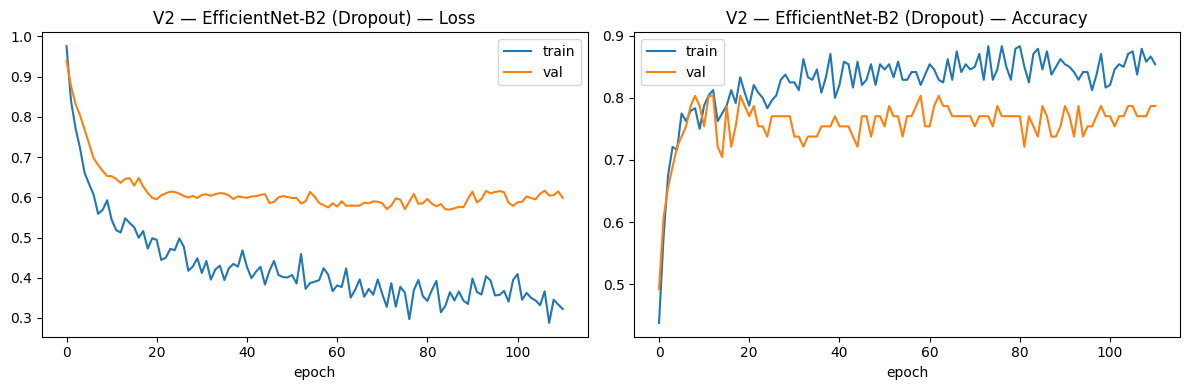

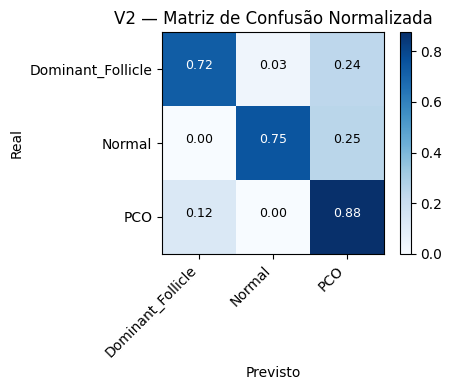

                   precision    recall  f1-score   support

Dominant_Follicle       0.88      0.72      0.79        29
           Normal       0.86      0.75      0.80         8
              PCO       0.70      0.88      0.78        24

         accuracy                           0.79        61
        macro avg       0.81      0.78      0.79        61
     weighted avg       0.80      0.79      0.79        61



In [13]:
plot_curves(hist_v2, "V2 — EfficientNet-B2 (Dropout)")
plot_cm(yt_v2, yp_v2, CLASS_NAMES, "V2", normalize=True)
print(classification_report(yt_v2, yp_v2, target_names=CLASS_NAMES))


> **Observação V2:** *(preencher após execução)*

---
## V3 · Leve — EfficientNet-B2 (último bloco livre)

| Parâmetro | Valor |
|---|---|
| Backbone | EfficientNet-B2 — último MBConv livre |
| Cabeça | FC(512) + Dropout(0.3) + FC |
| Augmentation | Flip H/V + Rotação ±15° |
| Scheduler | Nenhum |
| Épocas | 22 |
| Resolução | 224 |
| LR | 1e-4 |

**Objetivo:** início do fine-tuning sutil — observar ganho real ao descongelar 1 bloco.


In [14]:
def build_v3():
    weights = EfficientNet_B2_Weights.IMAGENET1K_V1
    model = efficientnet_b2(weights=weights)
    for p in model.parameters():
        p.requires_grad = False
    # último MBConv (features[-2]) + head conv (features[-1])
    for p in model.features[-2].parameters():
        p.requires_grad = True
    for p in model.features[-1].parameters():
        p.requires_grad = True
    in_feats = model.classifier[-1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(in_feats, 512),
        nn.SiLU(),
        nn.Dropout(0.3),
        nn.Linear(512, NUM_CLASSES),
    )
    return model.to(device)

train_tfms_v3, val_tfms_v3 = get_transforms("light", img_size=224)
train_loader_v3, val_loader_v3 = make_loaders(train_tfms_v3, val_tfms_v3, batch_size=32)

model_v3 = build_v3()
print(f"Parâmetros treináveis: {sum(p.numel() for p in model_v3.parameters() if p.requires_grad):,}")


Parâmetros treináveis: 3,957,199


In [15]:
print("\n=== Treinando V3 ===")
model_v3, hist_v3, res_v3, yt_v3, yp_v3 = train_model(
    model_v3, train_loader_v3, val_loader_v3,
    epochs=1000,
    lr=1e-4,
    var_name="V3 EffNet-B2 last-block",
)
res_v3["backbone"] = "EffNet-B2 (último bloco)"
ALL_RESULTS.append(res_v3)
show_results(res_v3)

save_model(model_v3, res_v3["variacao"])


=== Treinando V3 ===
  [  1/1000] loss 1.0155/0.9509  acc 0.5167/0.4754  f1_val 0.2148
  [  2/1000] loss 0.8621/0.8439  acc 0.5875/0.5738  f1_val 0.5159
  [  3/1000] loss 0.7790/0.7886  acc 0.5958/0.5738  f1_val 0.5159
  [  4/1000] loss 0.6952/0.7642  acc 0.7375/0.5738  f1_val 0.5595
  [  5/1000] loss 0.6765/0.7189  acc 0.6958/0.6885  f1_val 0.7024
  [  6/1000] loss 0.6108/0.6781  acc 0.7833/0.7213  f1_val 0.7520
  [  7/1000] loss 0.5628/0.6353  acc 0.8042/0.7213  f1_val 0.7546
  [  8/1000] loss 0.5504/0.5896  acc 0.7833/0.7869  f1_val 0.8045
  [  9/1000] loss 0.4968/0.5549  acc 0.8083/0.8033  f1_val 0.8167
  [ 10/1000] loss 0.4761/0.5287  acc 0.8125/0.8197  f1_val 0.8292
  [ 11/1000] loss 0.4406/0.5085  acc 0.8292/0.8033  f1_val 0.8166
  [ 12/1000] loss 0.4171/0.4978  acc 0.8292/0.7541  f1_val 0.7783
  [ 13/1000] loss 0.3997/0.4813  acc 0.8375/0.8197  f1_val 0.8292
  [ 14/1000] loss 0.4014/0.4718  acc 0.8167/0.8197  f1_val 0.8292
  [ 15/1000] loss 0.3399/0.4728  acc 0.8625/0.8197  f1

WindowsPath('modelos_salvos/membro1/membro1_V3_EffNet-B2_last-block.joblib')

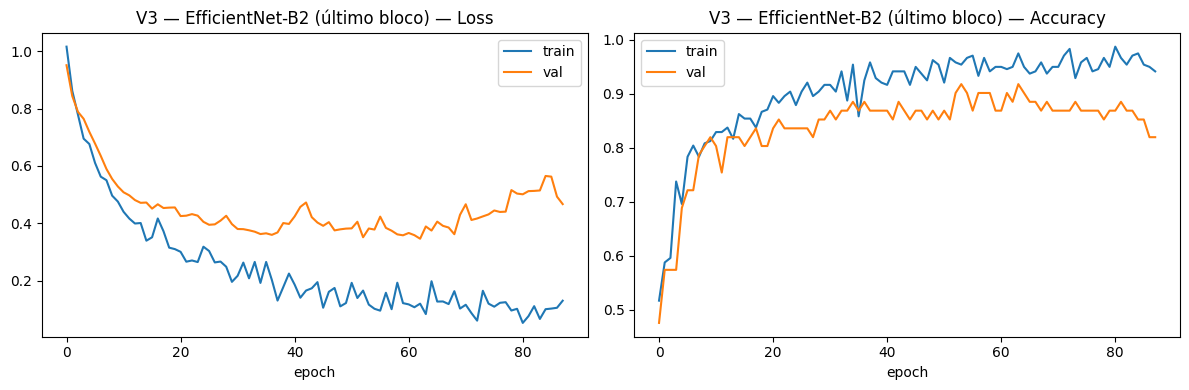

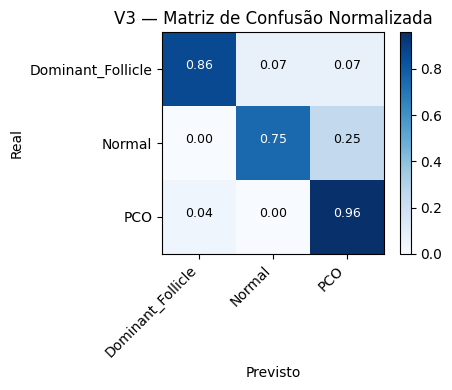

                   precision    recall  f1-score   support

Dominant_Follicle       0.96      0.86      0.91        29
           Normal       0.75      0.75      0.75         8
              PCO       0.85      0.96      0.90        24

         accuracy                           0.89        61
        macro avg       0.85      0.86      0.85        61
     weighted avg       0.89      0.89      0.89        61



In [16]:
plot_curves(hist_v3, "V3 — EfficientNet-B2 (último bloco)")
plot_cm(yt_v3, yp_v3, CLASS_NAMES, "V3", normalize=True)
print(classification_report(yt_v3, yp_v3, target_names=CLASS_NAMES))


> **Observação V3:** *(preencher após execução)*

---
## V4 · Leve — EfficientNet-B2 (último bloco + Scheduler)

| Parâmetro | Valor |
|---|---|
| Backbone | EfficientNet-B2 — último MBConv livre |
| Cabeça | FC(512) + BN + Dropout(0.35) + FC |
| Augmentation | Flip + ColorJitter leve |
| Scheduler | ReduceLROnPlateau (patience=4) |
| Épocas | 25 |
| Resolução | 224 |
| LR | 1e-4 |

**Objetivo:** scheduler entra pela 1ª vez — verifica estabilização do treino.


In [17]:
def build_v4():
    weights = EfficientNet_B2_Weights.IMAGENET1K_V1
    model = efficientnet_b2(weights=weights)
    for p in model.parameters():
        p.requires_grad = False
    for p in model.features[-2].parameters():
        p.requires_grad = True
    for p in model.features[-1].parameters():
        p.requires_grad = True
    in_feats = model.classifier[-1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(0.35),
        nn.Linear(in_feats, 512),
        nn.BatchNorm1d(512),
        nn.SiLU(),
        nn.Dropout(0.35),
        nn.Linear(512, NUM_CLASSES),
    )
    return model.to(device)

train_tfms_v4, val_tfms_v4 = get_transforms("light_jitter", img_size=224)
train_loader_v4, val_loader_v4 = make_loaders(train_tfms_v4, val_tfms_v4, batch_size=32)

model_v4 = build_v4()
print(f"Parâmetros treináveis: {sum(p.numel() for p in model_v4.parameters() if p.requires_grad):,}")


Parâmetros treináveis: 3,958,223


In [18]:
print("\n=== Treinando V4 ===")
model_v4, hist_v4, res_v4, yt_v4, yp_v4 = train_model(
    model_v4, train_loader_v4, val_loader_v4,
    epochs=1000,
    lr=1e-4,
    scheduler_fn=lambda opt: torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', patience=4, factor=0.5),
    var_name="V4 EffNet-B2 +Scheduler",
)
res_v4["backbone"] = "EffNet-B2 (último + Sched)"
ALL_RESULTS.append(res_v4)
show_results(res_v4)

save_model(model_v4, res_v4["variacao"])


=== Treinando V4 ===
  [  1/1000] loss 1.1185/1.0071  acc 0.3458/0.5902  f1_val 0.5520
  [  2/1000] loss 0.8993/0.9450  acc 0.5458/0.6230  f1_val 0.6142
  [  3/1000] loss 0.8575/0.8757  acc 0.5708/0.5902  f1_val 0.5463
  [  4/1000] loss 0.7674/0.8499  acc 0.6833/0.6885  f1_val 0.6586
  [  5/1000] loss 0.6703/0.7819  acc 0.7333/0.6721  f1_val 0.6368
  [  6/1000] loss 0.6379/0.6902  acc 0.7958/0.7869  f1_val 0.7462
  [  7/1000] loss 0.5569/0.6275  acc 0.7958/0.7869  f1_val 0.7665
  [  8/1000] loss 0.5629/0.5975  acc 0.7792/0.7705  f1_val 0.7766
  [  9/1000] loss 0.5524/0.5866  acc 0.7708/0.7541  f1_val 0.7634
  [ 10/1000] loss 0.5133/0.5515  acc 0.8250/0.8033  f1_val 0.8023
  [ 11/1000] loss 0.4559/0.5132  acc 0.8375/0.8689  f1_val 0.8523
  [ 12/1000] loss 0.5165/0.4992  acc 0.7875/0.8361  f1_val 0.8416
  [ 13/1000] loss 0.4555/0.4830  acc 0.8167/0.8361  f1_val 0.8416
  [ 14/1000] loss 0.3803/0.4734  acc 0.8500/0.8361  f1_val 0.8416
  [ 15/1000] loss 0.4269/0.4837  acc 0.8292/0.8361  f1

WindowsPath('modelos_salvos/membro1/membro1_V4_EffNet-B2_+Scheduler.joblib')

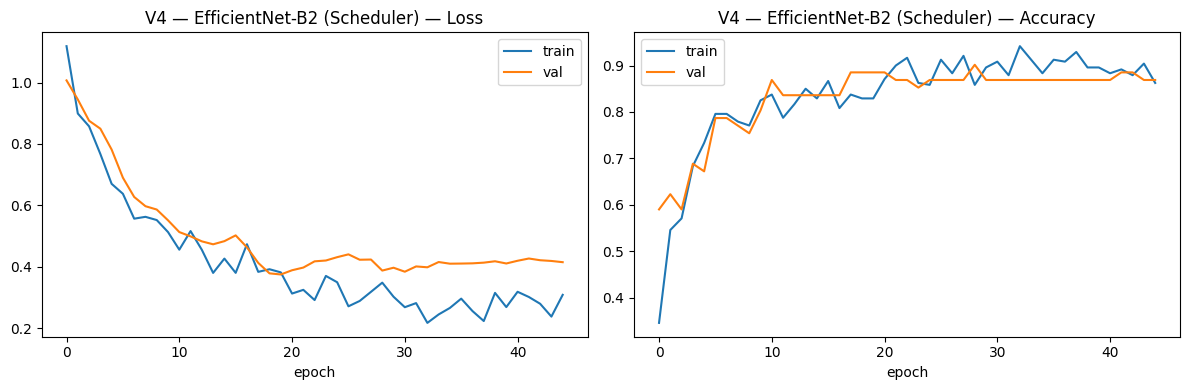

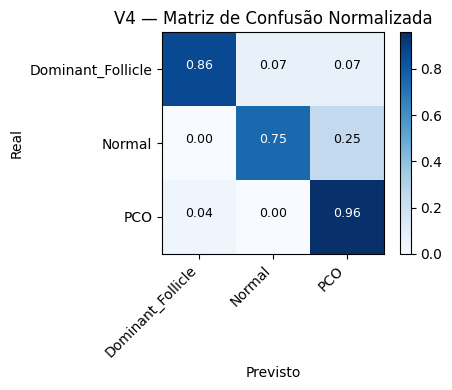

                   precision    recall  f1-score   support

Dominant_Follicle       0.96      0.86      0.91        29
           Normal       0.75      0.75      0.75         8
              PCO       0.85      0.96      0.90        24

         accuracy                           0.89        61
        macro avg       0.85      0.86      0.85        61
     weighted avg       0.89      0.89      0.89        61



In [19]:
plot_curves(hist_v4, "V4 — EfficientNet-B2 (Scheduler)")
plot_cm(yt_v4, yp_v4, CLASS_NAMES, "V4", normalize=True)
print(classification_report(yt_v4, yp_v4, target_names=CLASS_NAMES))


> **Observação V4:** *(preencher após execução)*

---
## V5 · Médio — EfficientNet-B2 (2 blocos livres, aug moderada)

| Parâmetro | Valor |
|---|---|
| Backbone | EfficientNet-B2 — 2 últimos MBConv livres |
| Cabeça | FC(768) + BN + Dropout(0.4) + FC |
| Augmentation | Flip + Rot + Jitter + Blur |
| Scheduler | ReduceLROnPlateau (patience=5) |
| Épocas | 35 |
| Resolução | 224 |
| LR | 5e-5 |

**Objetivo:** aumentar a capacidade de fine-tuning, observar risco de overfit.


In [20]:
def build_v5():
    weights = EfficientNet_B2_Weights.IMAGENET1K_V1
    model = efficientnet_b2(weights=weights)
    for p in model.parameters():
        p.requires_grad = False
    # 2 últimos blocos MBConv + head conv
    for p in model.features[-3].parameters():
        p.requires_grad = True
    for p in model.features[-2].parameters():
        p.requires_grad = True
    for p in model.features[-1].parameters():
        p.requires_grad = True
    in_feats = model.classifier[-1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(in_feats, 768),
        nn.BatchNorm1d(768),
        nn.SiLU(),
        nn.Dropout(0.4),
        nn.Linear(768, NUM_CLASSES),
    )
    return model.to(device)

train_tfms_v5, val_tfms_v5 = get_transforms("moderate", img_size=224)
train_loader_v5, val_loader_v5 = make_loaders(train_tfms_v5, val_tfms_v5, batch_size=24)

model_v5 = build_v5()
print(f"Parâmetros treináveis: {sum(p.numel() for p in model_v5.parameters() if p.requires_grad):,}")


Parâmetros treináveis: 7,369,085


In [21]:
print("\n=== Treinando V5 ===")
model_v5, hist_v5, res_v5, yt_v5, yp_v5 = train_model(
    model_v5, train_loader_v5, val_loader_v5,
    epochs=1000,
    lr=5e-5,
    scheduler_fn=lambda opt: torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', patience=5, factor=0.5),
    var_name="V5 EffNet-B2 2-blocks",
)
res_v5["backbone"] = "EffNet-B2 (2 blocos)"
ALL_RESULTS.append(res_v5)
show_results(res_v5)

save_model(model_v5, res_v5["variacao"])


=== Treinando V5 ===
  [  1/1000] loss 1.0951/1.0308  acc 0.3875/0.6721  f1_val 0.7006
  [  2/1000] loss 1.0048/0.9452  acc 0.4833/0.7049  f1_val 0.7056
  [  3/1000] loss 0.8939/0.8860  acc 0.5750/0.6721  f1_val 0.6420
  [  4/1000] loss 0.8725/0.8710  acc 0.5875/0.6721  f1_val 0.6389
  [  5/1000] loss 0.7763/0.8187  acc 0.6417/0.6557  f1_val 0.6257
  [  6/1000] loss 0.7250/0.7095  acc 0.6625/0.7705  f1_val 0.7317
  [  7/1000] loss 0.7164/0.6640  acc 0.7083/0.7705  f1_val 0.7285
  [  8/1000] loss 0.6051/0.6252  acc 0.7917/0.7869  f1_val 0.7539
  [  9/1000] loss 0.6032/0.6127  acc 0.7750/0.8033  f1_val 0.7665
  [ 10/1000] loss 0.5625/0.5736  acc 0.7958/0.8033  f1_val 0.7807
  [ 11/1000] loss 0.5690/0.5367  acc 0.7917/0.8033  f1_val 0.7728
  [ 12/1000] loss 0.4886/0.5019  acc 0.8292/0.8361  f1_val 0.8160
  [ 13/1000] loss 0.4743/0.5183  acc 0.8375/0.8033  f1_val 0.7735
  [ 14/1000] loss 0.4382/0.5186  acc 0.8500/0.8033  f1_val 0.7728
  [ 15/1000] loss 0.4274/0.4887  acc 0.8250/0.8033  f1

WindowsPath('modelos_salvos/membro1/membro1_V5_EffNet-B2_2-blocks.joblib')

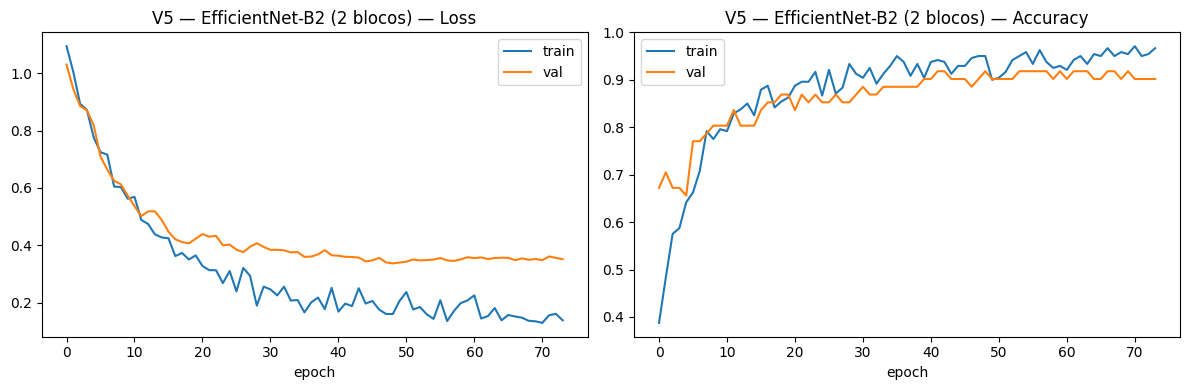

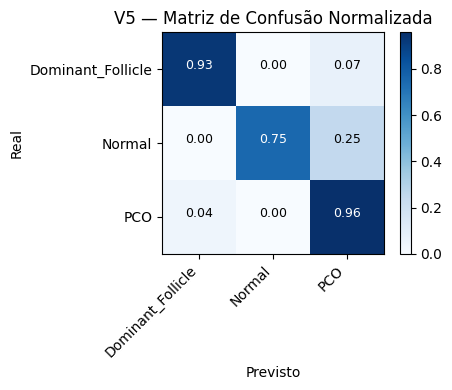

                   precision    recall  f1-score   support

Dominant_Follicle       0.96      0.93      0.95        29
           Normal       1.00      0.75      0.86         8
              PCO       0.85      0.96      0.90        24

         accuracy                           0.92        61
        macro avg       0.94      0.88      0.90        61
     weighted avg       0.92      0.92      0.92        61



In [22]:
plot_curves(hist_v5, "V5 — EfficientNet-B2 (2 blocos)")
plot_cm(yt_v5, yp_v5, CLASS_NAMES, "V5", normalize=True)
print(classification_report(yt_v5, yp_v5, target_names=CLASS_NAMES))


> **Observação V5:** *(preencher após execução)*

---
## V6 · Médio — EfficientNet-B2 (2 blocos, 256px)

| Parâmetro | Valor |
|---|---|
| Backbone | EfficientNet-B2 — 2 últimos MBConv livres |
| Cabeça | FC(1024) + BN + Dropout(0.45) + FC |
| Augmentation | Flip + Rot + Jitter + RandomCrop |
| Scheduler | StepLR (γ=0.5, step=10) |
| Épocas | 40 |
| Resolução | **256** |
| LR | 5e-5 |

**Objetivo:** testar ganho do aumento de resolução (224→256).


In [23]:
def build_v6():
    weights = EfficientNet_B2_Weights.IMAGENET1K_V1
    model = efficientnet_b2(weights=weights)
    for p in model.parameters():
        p.requires_grad = False
    for p in model.features[-3].parameters():
        p.requires_grad = True
    for p in model.features[-2].parameters():
        p.requires_grad = True
    for p in model.features[-1].parameters():
        p.requires_grad = True
    in_feats = model.classifier[-1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(0.45),
        nn.Linear(in_feats, 1024),
        nn.BatchNorm1d(1024),
        nn.SiLU(),
        nn.Dropout(0.45),
        nn.Linear(1024, NUM_CLASSES),
    )
    return model.to(device)

train_tfms_v6, val_tfms_v6 = get_transforms("moderate_crop", img_size=256)
train_loader_v6, val_loader_v6 = make_loaders(train_tfms_v6, val_tfms_v6, batch_size=16)

model_v6 = build_v6()
print(f"Parâmetros treináveis: {sum(p.numel() for p in model_v6.parameters() if p.requires_grad):,}")


Parâmetros treináveis: 7,731,069


In [24]:
print("\n=== Treinando V6 ===")
model_v6, hist_v6, res_v6, yt_v6, yp_v6 = train_model(
    model_v6, train_loader_v6, val_loader_v6,
    epochs=1000,
    lr=5e-5,
    scheduler_fn=lambda opt: torch.optim.lr_scheduler.StepLR(opt, step_size=10, gamma=0.5),
    var_name="V6 EffNet-B2 256px",
)
res_v6["backbone"] = "EffNet-B2 (2bl, 256)"
ALL_RESULTS.append(res_v6)
show_results(res_v6)

save_model(model_v6, res_v6["variacao"])


=== Treinando V6 ===
  [  1/1000] loss 1.0760/1.0165  acc 0.4208/0.5574  f1_val 0.4839
  [  2/1000] loss 0.8904/0.9501  acc 0.5667/0.5738  f1_val 0.4996
  [  3/1000] loss 0.8826/0.8101  acc 0.5417/0.6393  f1_val 0.6167
  [  4/1000] loss 0.7808/0.7427  acc 0.6167/0.6557  f1_val 0.6267
  [  5/1000] loss 0.7508/0.7252  acc 0.6500/0.7705  f1_val 0.7404
  [  6/1000] loss 0.6752/0.6677  acc 0.7208/0.8033  f1_val 0.7714
  [  7/1000] loss 0.5920/0.5910  acc 0.7500/0.8197  f1_val 0.8028
  [  8/1000] loss 0.5773/0.5346  acc 0.7667/0.8525  f1_val 0.8534
  [  9/1000] loss 0.4927/0.5197  acc 0.8375/0.8689  f1_val 0.8523
  [ 10/1000] loss 0.5077/0.4735  acc 0.7792/0.8525  f1_val 0.8285
  [ 11/1000] loss 0.4530/0.4399  acc 0.8375/0.8689  f1_val 0.8519
  [ 12/1000] loss 0.4641/0.4515  acc 0.8250/0.8525  f1_val 0.8285
  [ 13/1000] loss 0.4621/0.4294  acc 0.8250/0.8525  f1_val 0.8285
  [ 14/1000] loss 0.4603/0.4058  acc 0.8125/0.8689  f1_val 0.8410
  [ 15/1000] loss 0.4685/0.4013  acc 0.8292/0.8689  f1

WindowsPath('modelos_salvos/membro1/membro1_V6_EffNet-B2_256px.joblib')

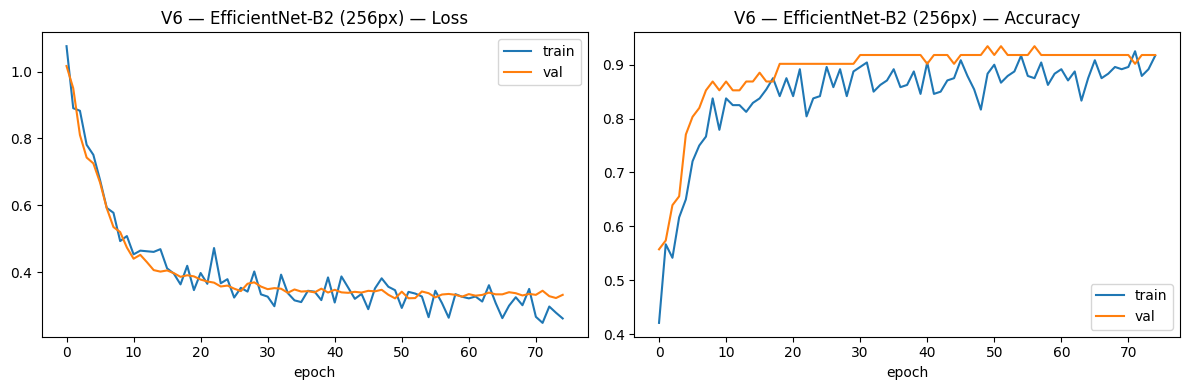

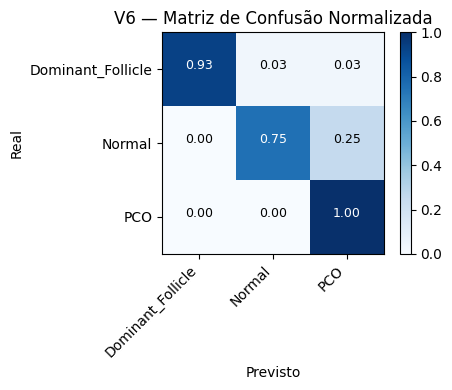

                   precision    recall  f1-score   support

Dominant_Follicle       1.00      0.93      0.96        29
           Normal       0.86      0.75      0.80         8
              PCO       0.89      1.00      0.94        24

         accuracy                           0.93        61
        macro avg       0.92      0.89      0.90        61
     weighted avg       0.94      0.93      0.93        61



In [25]:
plot_curves(hist_v6, "V6 — EfficientNet-B2 (256px)")
plot_cm(yt_v6, yp_v6, CLASS_NAMES, "V6", normalize=True)
print(classification_report(yt_v6, yp_v6, target_names=CLASS_NAMES))


> **Observação V6:** *(preencher após execução)*

---
## V7/V8 · Pesado — Helpers CutMix

In [26]:
import torch.nn.functional as F

def rand_bbox(size, lam):
    W, H = size[2], size[3]
    cut_rat = np.sqrt(1 - lam)
    cut_w, cut_h = int(W * cut_rat), int(H * cut_rat)
    cx, cy = np.random.randint(W), np.random.randint(H)
    bbx1 = np.clip(cx - cut_w // 2, 0, W)
    bby1 = np.clip(cy - cut_h // 2, 0, H)
    bbx2 = np.clip(cx + cut_w // 2, 0, W)
    bby2 = np.clip(cy + cut_h // 2, 0, H)
    return bbx1, bby1, bbx2, bby2

def cutmix_data(x, y, alpha=0.4):
    """CutMix simples: retorna x_mix, y_a, y_b, lam."""
    lam = np.random.beta(alpha, alpha)
    rand_idx = torch.randperm(x.size(0)).to(device)
    y_a, y_b = y, y[rand_idx]
    bbx1, bby1, bbx2, bby2 = rand_bbox(x.size(), lam)
    x_mix = x.clone()
    x_mix[:, :, bbx1:bbx2, bby1:bby2] = x[rand_idx, :, bbx1:bbx2, bby1:bby2]
    lam = 1 - (bbx2-bbx1)*(bby2-bby1) / (x.size(-1)*x.size(-2))
    return x_mix, y_a, y_b, lam

def train_cutmix_epoch(model, loader, optimizer, criterion, cutmix_prob=0.5):
    """Época com CutMix aplicado com probabilidade cutmix_prob."""
    model.train()
    total_loss, total_correct, total = 0.0, 0, 0
    all_preds, all_targets = [], []
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        if np.random.rand() < cutmix_prob:
            X_mix, y_a, y_b, lam = cutmix_data(X, y)
            logits = model(X_mix)
            loss = lam * criterion(logits, y_a) + (1-lam) * criterion(logits, y_b)
        else:
            logits = model(X)
            loss = criterion(logits, y)
        loss.backward(); optimizer.step()
        preds = logits.argmax(1)
        total_loss    += loss.item() * y.size(0)
        total_correct += (preds == y).sum().item()
        total         += y.size(0)
        all_preds.append(preds.detach().cpu().numpy())
        all_targets.append(y.detach().cpu().numpy())
    avg_loss = total_loss / total
    acc      = total_correct / total
    y_true   = np.concatenate(all_targets)
    y_pred   = np.concatenate(all_preds)
    f1       = f1_score(y_true, y_pred, average="macro", zero_division=0)
    return avg_loss, acc, f1, y_true, y_pred

print("✅ Funções CutMix prontas")


✅ Funções CutMix prontas


---
## V7 · Pesado — EfficientNet-B3 (FT completo + TTA)

| Parâmetro | Valor |
|---|---|
| Backbone | EfficientNet-**B3** — FT completo (LR diff: backbone 1e-5 / cabeça 1e-4) |
| Cabeça | FC(1024) + BN + Dropout(0.5) + FC |
| Augmentation | CutMix + RandomErasing |
| Scheduler | CosineAnnealingLR |
| Épocas | 55 |
| Resolução | 256 |
| Extras | TTA na avaliação final |

**Objetivo:** FT completo no backbone maior com regularização forte. Candidato ao ensemble.


In [27]:
def build_v7():
    weights = EfficientNet_B3_Weights.IMAGENET1K_V1
    model = efficientnet_b3(weights=weights)
    for p in model.parameters():
        p.requires_grad = True
    in_feats = model.classifier[-1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(in_feats, 1024),
        nn.BatchNorm1d(1024),
        nn.SiLU(),
        nn.Dropout(0.5),
        nn.Linear(1024, NUM_CLASSES),
    )
    return model.to(device)

train_tfms_v7, val_tfms_v7 = get_transforms("heavy", img_size=256)
train_loader_v7, val_loader_v7 = make_loaders(train_tfms_v7, val_tfms_v7, batch_size=16)

model_v7 = build_v7()
print(f"Parâmetros treináveis: {sum(p.numel() for p in model_v7.parameters() if p.requires_grad):,}")


Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to C:\Users\brian/.cache\torch\hub\checkpoints\efficientnet_b3_rwightman-b3899882.pth
100%|██████████| 47.2M/47.2M [00:00<00:00, 58.4MB/s]


Parâmetros treináveis: 12,275,243


In [28]:
EPOCHS_V7 = 55
criterion_v7 = nn.CrossEntropyLoss(label_smoothing=0.0)
optimizer_v7 = torch.optim.AdamW([
    {"params": model_v7.features.parameters(), "lr": 1e-05},
    {"params": model_v7.classifier.parameters(),     "lr": 0.0001},
], weight_decay=0.0001)
scheduler_v7 = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_v7, T_max=EPOCHS_V7, eta_min=1e-7)

print("\n=== Treinando V7 (FT completo) ===")
history_v7 = {k: [] for k in ["train_loss","val_loss","train_acc","val_acc","val_f1"]}
best_f1_v7, best_state_v7 = 0.0, None
yt_v7, yp_v7 = None, None
t0_v7 = time.time()

for e in range(1, EPOCHS_V7 + 1):
    tr_loss, tr_acc, _, _, _       = train_cutmix_epoch(model_v7, train_loader_v7, optimizer_v7, criterion_v7)
    va_loss, va_acc, va_f1, yt, yp = run_epoch(model_v7, val_loader_v7, optimizer_v7, criterion_v7, train=False)
    scheduler_v7.step()

    for k, v in zip(history_v7.keys(), [tr_loss, va_loss, tr_acc, va_acc, va_f1]):
        history_v7[k].append(v)
    if va_f1 > best_f1_v7:
        best_f1_v7, best_state_v7 = va_f1, deepcopy(model_v7.state_dict())
        yt_v7, yp_v7 = yt, yp
    print(f"  [{e:>3}/{EPOCHS_V7}] loss {tr_loss:.4f}/{va_loss:.4f}  acc {tr_acc:.4f}/{va_acc:.4f}  f1 {va_f1:.4f}")

model_v7.load_state_dict(best_state_v7)
elapsed_v7 = (time.time() - t0_v7) / 60

print("  → Aplicando TTA...")
tta_acc_v7, tta_f1_v7, yt_v7, yp_v7 = tta_predict(model_v7, val_loader_v7, img_size=256)
print(f"  TTA  acc={tta_acc_v7:.4f}  f1={tta_f1_v7:.4f}")

res_v7 = {
    "variacao": "V7 EffNet-B3 FT+TTA",
    "backbone": "EffNet-B3 (FT completo, TTA)",
    "accuracy": round(tta_acc_v7, 4),
    "f1_macro": round(tta_f1_v7,  4),
    "precision": round(precision_score(yt_v7, yp_v7, average="macro", zero_division=0), 4),
    "recall":    round(recall_score(yt_v7, yp_v7, average="macro", zero_division=0), 4),
    "loss":      round(history_v7["val_loss"][-1], 4),
    "tempo_min": round(elapsed_v7, 1),
}
ALL_RESULTS.append(res_v7)
show_results(res_v7)

save_model(model_v7, res_v7["variacao"])



=== Treinando V7 (FT completo) ===
  [  1/55] loss 1.1431/1.0435  acc 0.3500/0.5902  f1 0.5579
  [  2/55] loss 1.0053/0.9191  acc 0.4792/0.6557  f1 0.6508
  [  3/55] loss 0.9373/0.8185  acc 0.4958/0.7213  f1 0.7319
  [  4/55] loss 0.8536/0.7733  acc 0.6083/0.6393  f1 0.6361
  [  5/55] loss 0.8880/0.7548  acc 0.5542/0.7377  f1 0.7534
  [  6/55] loss 0.8075/0.7574  acc 0.6125/0.7213  f1 0.7362
  [  7/55] loss 0.8438/0.6975  acc 0.6042/0.7213  f1 0.7524
  [  8/55] loss 0.7342/0.6824  acc 0.6375/0.7213  f1 0.7446
  [  9/55] loss 0.7019/0.6580  acc 0.6875/0.7213  f1 0.7446
  [ 10/55] loss 0.6787/0.6389  acc 0.7000/0.7705  f1 0.7873
  [ 11/55] loss 0.8310/0.6296  acc 0.5917/0.7541  f1 0.7688
  [ 12/55] loss 0.6728/0.6421  acc 0.6542/0.7377  f1 0.7514
  [ 13/55] loss 0.7465/0.6237  acc 0.6333/0.7869  f1 0.7873
  [ 14/55] loss 0.6926/0.5942  acc 0.6708/0.7869  f1 0.7895
  [ 15/55] loss 0.7319/0.6164  acc 0.6708/0.7869  f1 0.7895
  [ 16/55] loss 0.6930/0.5860  acc 0.6625/0.8033  f1 0.8017
  [ 

WindowsPath('modelos_salvos/membro1/membro1_V7_EffNet-B3_FT+TTA.joblib')

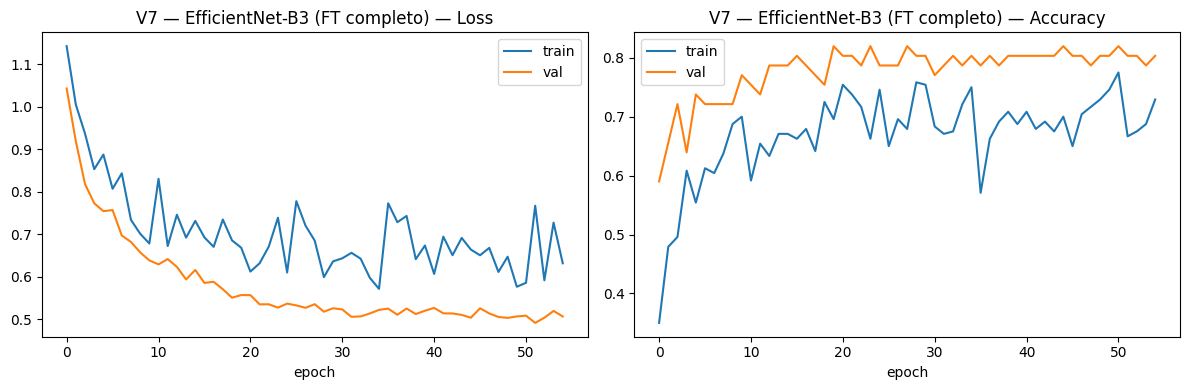

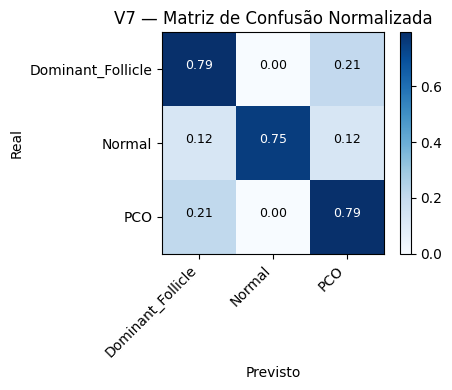

                   precision    recall  f1-score   support

Dominant_Follicle       0.79      0.79      0.79        29
           Normal       1.00      0.75      0.86         8
              PCO       0.73      0.79      0.76        24

         accuracy                           0.79        61
        macro avg       0.84      0.78      0.80        61
     weighted avg       0.80      0.79      0.79        61



In [29]:
plot_curves(history_v7, "V7 — EfficientNet-B3 (FT completo)")
plot_cm(yt_v7, yp_v7, CLASS_NAMES, "V7", normalize=True)
print(classification_report(yt_v7, yp_v7, target_names=CLASS_NAMES))


> **Observação V7:** *(preencher após execução)*

---
## V8 · Pesado — EfficientNet-B3 (FT completo + SE + RandAugment + Label Smoothing)

| Parâmetro | Valor |
|---|---|
| Backbone | EfficientNet-**B3** — FT completo (LR diff) |
| Cabeça | FC(1024) + BN + **SE block** + Dropout(0.5) + FC |
| Augmentation | CutMix + RandAugment |
| Scheduler | CosineAnnealingWarmRestarts |
| Épocas | 60 |
| Resolução | **299** |
| Extras | Label Smoothing 0.1, WD=1e-4, TTA |

**Objetivo:** principal candidato ao ensemble — maior modelo, regularização máxima.


In [30]:
class SELayer1d(nn.Module):
    """Squeeze-and-Excitation aplicado em features flat (channel-wise gating)."""
    def __init__(self, channels: int, reduction: int = 16):
        super().__init__()
        hidden = max(channels // reduction, 4)
        self.gate = nn.Sequential(
            nn.Linear(channels, hidden),
            nn.SiLU(),
            nn.Linear(hidden, channels),
            nn.Sigmoid(),
        )
    def forward(self, x):
        return x * self.gate(x)

def build_v8():
    weights = EfficientNet_B3_Weights.IMAGENET1K_V1
    model = efficientnet_b3(weights=weights)
    for p in model.parameters():
        p.requires_grad = True
    in_feats = model.classifier[-1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(in_feats, 1024),
        nn.BatchNorm1d(1024),
        SELayer1d(1024),
        nn.SiLU(),
        nn.Dropout(0.5),
        nn.Linear(1024, NUM_CLASSES),
    )
    return model.to(device)

# Pipeline com RandAugment
def get_transforms_randaugment(img_size=299):
    normalize = transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
    train_tfms = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.RandAugment(num_ops=2, magnitude=9),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        normalize,
        transforms.RandomErasing(p=0.3, scale=(0.02, 0.2)),
    ])
    val_tfms = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        normalize,
    ])
    return train_tfms, val_tfms

train_tfms_v8, val_tfms_v8 = get_transforms_randaugment(img_size=299)
train_loader_v8, val_loader_v8 = make_loaders(train_tfms_v8, val_tfms_v8, batch_size=12)

model_v8 = build_v8()
print(f"Parâmetros treináveis: {sum(p.numel() for p in model_v8.parameters() if p.requires_grad):,}")


Parâmetros treináveis: 12,407,403


In [31]:
EPOCHS_V8 = 60
criterion_v8 = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer_v8 = torch.optim.AdamW([
    {"params": model_v8.features.parameters(), "lr": 1e-05},
    {"params": model_v8.classifier.parameters(),     "lr": 0.0001},
], weight_decay=0.0001)
scheduler_v8 = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer_v8, T_0=20, T_mult=2)

print("\n=== Treinando V8 (FT completo) ===")
history_v8 = {k: [] for k in ["train_loss","val_loss","train_acc","val_acc","val_f1"]}
best_f1_v8, best_state_v8 = 0.0, None
yt_v8, yp_v8 = None, None
t0_v8 = time.time()

for e in range(1, EPOCHS_V8 + 1):
    tr_loss, tr_acc, _, _, _       = train_cutmix_epoch(model_v8, train_loader_v8, optimizer_v8, criterion_v8)
    va_loss, va_acc, va_f1, yt, yp = run_epoch(model_v8, val_loader_v8, optimizer_v8, criterion_v8, train=False)
    scheduler_v8.step()

    for k, v in zip(history_v8.keys(), [tr_loss, va_loss, tr_acc, va_acc, va_f1]):
        history_v8[k].append(v)
    if va_f1 > best_f1_v8:
        best_f1_v8, best_state_v8 = va_f1, deepcopy(model_v8.state_dict())
        yt_v8, yp_v8 = yt, yp
    print(f"  [{e:>3}/{EPOCHS_V8}] loss {tr_loss:.4f}/{va_loss:.4f}  acc {tr_acc:.4f}/{va_acc:.4f}  f1 {va_f1:.4f}")

model_v8.load_state_dict(best_state_v8)
elapsed_v8 = (time.time() - t0_v8) / 60

print("  → Aplicando TTA...")
tta_acc_v8, tta_f1_v8, yt_v8, yp_v8 = tta_predict(model_v8, val_loader_v8, img_size=299)
print(f"  TTA  acc={tta_acc_v8:.4f}  f1={tta_f1_v8:.4f}")

res_v8 = {
    "variacao": "V8 EffNet-B3 SE+TTA",
    "backbone": "EffNet-B3 (FT+SE, TTA)",
    "accuracy": round(tta_acc_v8, 4),
    "f1_macro": round(tta_f1_v8,  4),
    "precision": round(precision_score(yt_v8, yp_v8, average="macro", zero_division=0), 4),
    "recall":    round(recall_score(yt_v8, yp_v8, average="macro", zero_division=0), 4),
    "loss":      round(history_v8["val_loss"][-1], 4),
    "tempo_min": round(elapsed_v8, 1),
}
ALL_RESULTS.append(res_v8)
show_results(res_v8)

save_model(model_v8, res_v8["variacao"])



=== Treinando V8 (FT completo) ===
  [  1/60] loss 1.0600/1.0261  acc 0.4583/0.5902  f1 0.5825
  [  2/60] loss 0.9894/0.8994  acc 0.4958/0.7377  f1 0.7517
  [  3/60] loss 0.9504/0.8625  acc 0.5167/0.6557  f1 0.6999
  [  4/60] loss 0.9189/0.8319  acc 0.5542/0.7049  f1 0.7365
  [  5/60] loss 0.9020/0.8163  acc 0.5875/0.7377  f1 0.7653
  [  6/60] loss 0.9215/0.8059  acc 0.6000/0.7377  f1 0.7506
  [  7/60] loss 0.8651/0.7900  acc 0.6125/0.7377  f1 0.7612
  [  8/60] loss 0.8577/0.7725  acc 0.6375/0.7213  f1 0.7321
  [  9/60] loss 0.8324/0.7559  acc 0.7000/0.7541  f1 0.7750
  [ 10/60] loss 0.8223/0.7561  acc 0.6583/0.7377  f1 0.7612
  [ 11/60] loss 0.8385/0.7364  acc 0.6125/0.7869  f1 0.8031
  [ 12/60] loss 0.8098/0.7289  acc 0.6208/0.7705  f1 0.7901
  [ 13/60] loss 0.8084/0.7210  acc 0.6833/0.7705  f1 0.7901
  [ 14/60] loss 0.8193/0.7182  acc 0.6625/0.7869  f1 0.8031
  [ 15/60] loss 0.8035/0.7157  acc 0.7042/0.7705  f1 0.7864
  [ 16/60] loss 0.8472/0.7073  acc 0.6875/0.8033  f1 0.8135
  [ 

WindowsPath('modelos_salvos/membro1/membro1_V8_EffNet-B3_SE+TTA.joblib')

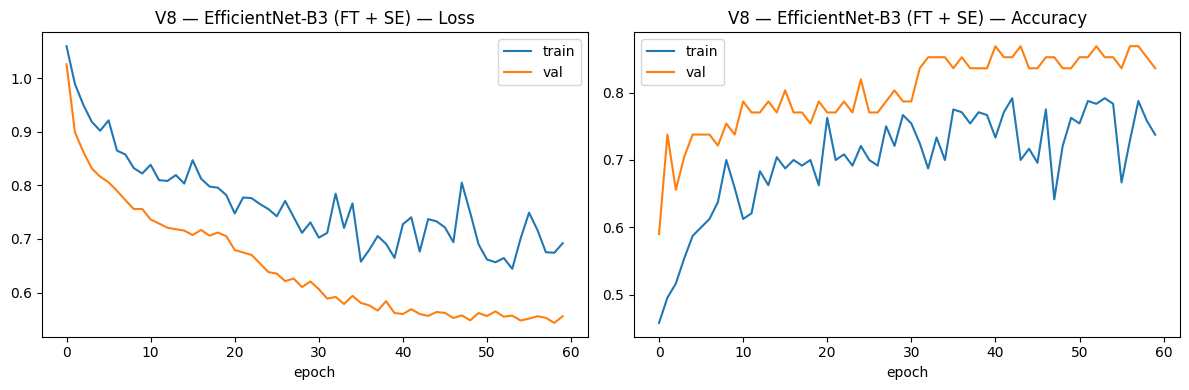

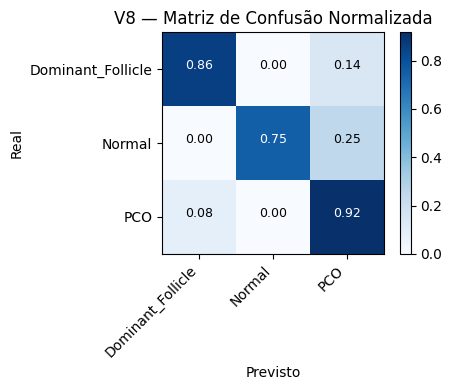

                   precision    recall  f1-score   support

Dominant_Follicle       0.93      0.86      0.89        29
           Normal       1.00      0.75      0.86         8
              PCO       0.79      0.92      0.85        24

         accuracy                           0.87        61
        macro avg       0.90      0.84      0.87        61
     weighted avg       0.88      0.87      0.87        61



In [32]:
plot_curves(history_v8, "V8 — EfficientNet-B3 (FT + SE)")
plot_cm(yt_v8, yp_v8, CLASS_NAMES, "V8", normalize=True)
print(classification_report(yt_v8, yp_v8, target_names=CLASS_NAMES))


> **Observação V8:** *(preencher após execução)*

---
## Consolidação Final — Todos os Resultados


In [33]:
print("\n=== TABELA CONSOLIDADA ===")
print_results_table()



=== TABELA CONSOLIDADA ===
Var    Backbone                          Acc     F1   Prec    Rec   Loss  Tempo
───────────────────────────────────────────────────────────────────────────────
V1 EffNet-B2 frozen EfficientNet-B2 (frozen)       0.7869 0.8010 0.8149 0.7898 0.5536  12.9m
V2 EffNet-B2 +Dropout EffNet-B2 (frozen+Drop)        0.7869 0.7901 0.8107 0.7830 0.5698  17.8m
V3 EffNet-B2 last-block EffNet-B2 (último bloco)       0.8197 0.8537 0.8545 0.8568 0.3467  14.2m
V4 EffNet-B2 +Scheduler EffNet-B2 (último + Sched)     0.8689 0.8537 0.8545 0.8568 0.3752   7.4m
V5 EffNet-B2 2-blocks EffNet-B2 (2 blocos)           0.9016 0.9022 0.9387 0.8798 0.3368  12.4m
V6 EffNet-B2 256px EffNet-B2 (2bl, 256)           0.9180 0.9018 0.9153 0.8937 0.3212  12.6m
V7 EffNet-B3 FT+TTA EffNet-B3 (FT completo, TTA)   0.7869 0.8034 0.8413 0.7783 0.5071  13.5m
V8 EffNet-B3 SE+TTA EffNet-B3 (FT+SE, TTA)         0.8689 0.8654 0.9039 0.8429 0.5558  22.4m


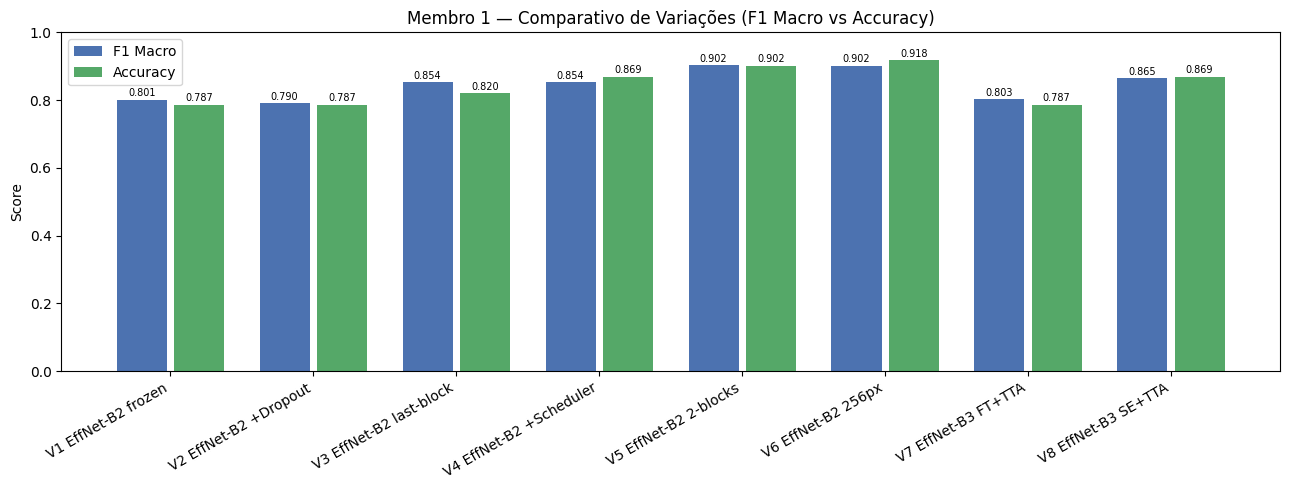

In [34]:
# Gráfico comparativo de F1 Macro entre variações
if ALL_RESULTS:
    nomes = [r["variacao"] for r in ALL_RESULTS]
    f1s   = [r["f1_macro"] for r in ALL_RESULTS]
    accs  = [r["accuracy"] for r in ALL_RESULTS]

    x = np.arange(len(nomes))
    fig, ax = plt.subplots(figsize=(13, 5))
    bars = ax.bar(x - 0.2, f1s,  0.35, label="F1 Macro", color="#4C72B0")
    bars2= ax.bar(x + 0.2, accs, 0.35, label="Accuracy",  color="#55A868")
    ax.set_xticks(x); ax.set_xticklabels(nomes, rotation=30, ha="right")
    ax.set_ylim(0, 1); ax.set_ylabel("Score"); ax.legend()
    ax.set_title("Membro 1 — Comparativo de Variações (F1 Macro vs Accuracy)")
    for b in list(bars) + list(bars2):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.01,
                f"{b.get_height():.3f}", ha="center", fontsize=7)
    plt.tight_layout(); plt.show()


---
## Notas para o Relatório

Copie esta tabela para o documento do grupo após preencher todas as variações:

| Var. | Backbone | Accuracy | F1 Macro | Precision | Recall | Tempo | Observações |
|---|---|---|---|---|---|---|---|
| V1 | EffNet-B2 frozen | | | | | | |
| V2 | EffNet-B2 frozen + Dropout | | | | | | |
| V3 | EffNet-B2 último bloco livre | | | | | | |
| V4 | EffNet-B2 último bloco + Scheduler | | | | | | |
| V5 | EffNet-B2 2 blocos livres | | | | | | |
| V6 | EffNet-B2 2 blocos 256px | | | | | | |
| V7 | EffNet-B3 FT completo + TTA | | | | | | |
| V8 | EffNet-B3 FT completo + SE + TTA | | | | | | |
